In [ ]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Phase-diagram overlay + local error analysis with **manual point selection**

This notebook is the same midpoint-window analysis as before, except the point selection is now **manual**.

Workflow:
1. Load the phase-diagram data and available SAFT-P grid points.
2. Show all available grid points on top of the phase diagrams.
3. Edit `MANUAL_POINT_REQUESTS` to choose the points you want.
4. The notebook snaps each request to the **nearest valid grid point** from the SAFT-P `.npz` data.
5. For each chosen point:
   - find the midpoint chemical potential
   - build a local `mu` window around it
   - compare MC, SAFT, and SAFT-P
   - report error metrics

You can specify either:
- exact grid values
- approximate values, which will be snapped to the nearest valid grid point


In [13]:
from dataclasses import dataclass
from pathlib import Path
import ast
import json
import re
import numpy as np
import pandas as pd
import numba as nb
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline, PchipInterpolator
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import minimize_scalar

# ===== paths =====
data_dir = Path(".")   # change if needed
from plaquette_by_species import *
from saft_analysis import *
from simulate_functions_min import *

FILES = {
    "saft_json": data_dir / "../data/spinodal2_saft.json",
    "l_saftp_base": data_dir / "../data/spinodal_l_reduced_square_use4patch",
    "stick_saftp_base": data_dir / "../data/spinodal_simple_reduced_square_use4patch",
    "l_mc_trace": data_dir / "../results_logs/all_trace_coexist_l.out",
    "stick_mc_trace": data_dir / "../results_logs/all_trace_coexist_stick.out",
}

# ===== system definitions =====
@dataclass(frozen=True)
class SystemConfig:
    name: str
    label: str
    patches: np.ndarray
    rot90_species: np.ndarray
    active_indices: np.ndarray
    occupied_degeneracy: int
    empty_index: int

SYSTEMS = {
    "stick": SystemConfig(
        name="stick",
        label="Stick",
        patches=np.array(
            [
                [1, 0, 1, 0],
                [0, 1, 0, 1],
                [2, 2, 2, 2],
            ],
            dtype=np.int16),
        rot90_species=np.array([1, 0, 2], dtype=np.int64),
        active_indices=np.array([0, 1], dtype=np.int64),
        occupied_degeneracy=2,
        empty_index=2,
    ),
    "l": SystemConfig(
        name="l",
        label="L-shaped",
        patches=np.array(
            [
                [1, 1, 0, 0],
                [0, 1, 1, 0],
                [0, 0, 1, 1],
                [1, 0, 0, 1],
                [2, 2, 2, 2],
            ],
            dtype=np.int16),
        rot90_species=np.array([1, 2, 3, 0, 4], dtype=np.int64),
        active_indices=np.array([0, 1, 2, 3], dtype=np.int64),
        occupied_degeneracy=4,
        empty_index=4,
    ),
}

# ===== midpoint / window controls =====
midpoint_reference = "mc"    # "mc" or "saftp"
target_midpoint = 0.5

mu_search_min = 0.0
mu_search_max = 8.0
mu_search_points = 17

mu_window_half_width = 1.25
mu_values_line_count = 161
mu_values_mc_count = 9

# midpoint search MC settings
mid_L = 20
mid_mc_steps = 25_000
mid_snapshot_interval = 250
mid_buffer_size = 2500
mid_block_size = 1000
mid_burn_fraction = 0.5
mid_replicates = 2

# ===== theory / MC settings =====
phi_grid = np.linspace(0.01, 0.99, 151)
beta = 1.0
z_assoc = 4.0

saftp_max_iter = 250
saftp_damping = 0.5
saftp_tol = 1e-9

L = 24
mc_steps = 80_000
snapshot_interval = 400
buffer_size = 5000
block_size = 1000
burn_fraction = 0.5
replicates = 3
rng_seed_base = 20260403

print("Data dir:", data_dir.resolve())


Data dir: <repo>


In [14]:

# ---------- ACS Nano figure style ----------
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "lines.markersize": 4.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

SINGLE_COL = 3.35
DOUBLE_COL = 7.0
PLOT_OUTDIR = data_dir / "acs_nano_figures"
PLOT_OUTDIR.mkdir(exist_ok=True)

def apply_axes_style(ax, *, xlabel=None, ylabel=None, xminor=True, yminor=True, show_grid=False):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if xminor:
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    if yminor:
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which="both", top=True, right=True)
    if show_grid:
        ax.grid(alpha=0.18, linewidth=0.5)
    else:
        ax.grid(False)

def panel_label(ax, text):
    ax.text(-0.14, 1.04, text, transform=ax.transAxes, fontsize=10, fontweight="bold", va="bottom", ha="left")

def save_figure(fig, stem):
    fig.savefig(PLOT_OUTDIR / f"{stem}.pdf")
    fig.savefig(PLOT_OUTDIR / f"{stem}.png", dpi=600)

print("ACS Nano figure style active. Output dir:", PLOT_OUTDIR.resolve())


ACS Nano figure style active. Output dir: <repo>/acs_nano_figures


In [15]:
# ---------- MC simulation kernel ----------

def precompute_bond_table_from_patches(J_patch, patches_by_species):
    Jp = np.asarray(J_patch, dtype=np.float64)
    P  = np.asarray(patches_by_species, dtype=np.int16)
    n_species = P.shape[0]
    B = np.empty((4, n_species, n_species), dtype=np.float64)
    for si in range(n_species):
        piN, piE, piS, piW = map(int, P[si])
        for sj in range(n_species):
            pjN, pjE, pjS, pjW = map(int, P[sj])
            B[0, si, sj] = Jp[piN, pjS]
            B[1, si, sj] = Jp[piE, pjW]
            B[2, si, sj] = Jp[piS, pjN]
            B[3, si, sj] = Jp[piW, pjE]
    return B

def make_mask(n_species, indices):
    mask = np.zeros(n_species, dtype=np.uint8)
    for idx in np.asarray(indices, dtype=np.int64).ravel():
        if 0 <= int(idx) < n_species:
            mask[int(idx)] = 1
    return mask

@nb.njit(cache=True, fastmath=True)
def _push_unique(buf, m, x):
    for i in range(m):
        if buf[i] == x:
            return m
    buf[m] = x
    return m + 1

@nb.njit(cache=True, fastmath=True)
def _local_energy_site(k, lat, nbr, Bdir):
    s = lat[k]
    n0 = lat[nbr[k, 0]]
    n1 = lat[nbr[k, 1]]
    n2 = lat[nbr[k, 2]]
    n3 = lat[nbr[k, 3]]
    return 0.5 * (Bdir[0, s, n0] + Bdir[1, s, n1] + Bdir[2, s, n2] + Bdir[3, s, n3])

@nb.njit(cache=True, fastmath=True)
def _bond_counts_right(s, sr, empty_index, P):
    if s == empty_index or sr == empty_index:
        return 0, 0
    tot = 1
    sp = 1 if (P[s, 1] == 1 and P[sr, 3] == 1) else 0
    return tot, sp

@nb.njit(cache=True, fastmath=True)
def _bond_counts_down(s, sd, empty_index, P):
    if s == empty_index or sd == empty_index:
        return 0, 0
    tot = 1
    sp = 1 if (P[s, 2] == 1 and P[sd, 0] == 1) else 0
    return tot, sp

@nb.njit(cache=True, fastmath=True)
def _mc_lattice_single_site_numba(
    lat2d_int, Bdir, P, mu,
    mask_mu, mask_ns, mask_ew,
    empty_index,
    eps_ns0, eps_sp0,
    simulation_steps, beta,
    snapshot_interval, buffer_size,
    block_size
):
    H, W = lat2d_int.shape
    N = H * W
    n_species = mu.shape[0]
    invN = 1.0 / N

    nbr = np.empty((N, 4), dtype=np.int32)
    for i in range(H):
        im = (i - 1) % H
        ip = (i + 1) % H
        for j in range(W):
            jm = (j - 1) % W
            jp = (j + 1) % W
            k = i * W + j
            nbr[k, 0] = im * W + j
            nbr[k, 1] = i  * W + jp
            nbr[k, 2] = ip * W + j
            nbr[k, 3] = i  * W + jm

    lat = lat2d_int.ravel().copy()

    counts = np.zeros(n_species, dtype=np.int64)
    for k in range(N):
        counts[lat[k]] += 1

    Nocc = N - counts[empty_index]
    Nmu = 0
    for s in range(n_species):
        if mask_mu[s] != 0:
            Nmu += counts[s]

    N_NS = 0
    N_EW = 0
    for s in range(n_species):
        if mask_ns[s] != 0:
            N_NS += counts[s]
        if mask_ew[s] != 0:
            N_EW += counts[s]

    C_tot = 0
    C_sp  = 0
    for i in range(H):
        for j in range(W):
            k = i * W + j
            s = lat[k]
            sr = lat[nbr[k, 1]]
            sd = lat[nbr[k, 2]]
            t, sp = _bond_counts_right(s, sr, empty_index, P)
            C_tot += t
            C_sp  += sp
            t, sp = _bond_counts_down(s, sd, empty_index, P)
            C_tot += t
            C_sp  += sp
    C_ns = C_tot - C_sp

    e_sites = np.empty(N, dtype=np.float64)
    energy = 0.0
    for k in range(N):
        ev = _local_energy_site(k, lat, nbr, Bdir)
        e_sites[k] = ev
        energy += ev
    for k in range(N):
        energy += mu[lat[k]]

    total_samples = 1 + simulation_steps // snapshot_interval
    n_keep = buffer_size
    if n_keep < 1:
        n_keep = 1
    if n_keep > total_samples:
        n_keep = total_samples

    energies_buf  = np.empty(n_keep, dtype=np.float64)
    densities_buf = np.empty((n_keep, n_species), dtype=np.float64)
    N_mu_buf      = np.empty(n_keep, dtype=np.int64)
    Nocc_buf      = np.empty(n_keep, dtype=np.int64)
    C_sp_buf      = np.empty(n_keep, dtype=np.int64)
    C_ns_buf      = np.empty(n_keep, dtype=np.int64)
    u_buf         = np.empty(n_keep, dtype=np.float64)
    Q_buf         = np.empty(n_keep, dtype=np.float64)

    n_blocks = simulation_steps // block_size
    acc_blocks = np.empty(n_blocks, dtype=np.float64)
    accepted_in_block = 0

    tries = 0
    accepts = 0

    buf5 = np.empty(5, dtype=np.int32)
    oldE = np.empty(5, dtype=np.float64)
    newE = np.empty(5, dtype=np.float64)

    sample_count = 0

    def record():
        nonlocal sample_count
        i = sample_count % n_keep
        energies_buf[i] = energy
        for s in range(n_species):
            densities_buf[i, s] = counts[s] * invN
        N_mu_buf[i]  = Nmu
        Nocc_buf[i]  = Nocc
        C_sp_buf[i]  = C_sp
        C_ns_buf[i]  = C_ns
        u_buf[i]     = -(C_ns * eps_ns0 + C_sp * eps_sp0) * invN
        Q_buf[i]     = (N_NS - N_EW) * invN
        sample_count += 1

    record()

    for step in range(simulation_steps):
        tries += 1
        k = np.random.randint(N)
        old_s = lat[k]
        new_s = np.random.randint(n_species)
        accepted = False

        if new_s == old_s:
            accepted = True
        else:
            m = 0
            m = _push_unique(buf5, m, k)
            for d in range(4):
                m = _push_unique(buf5, m, nbr[k, d])

            for t in range(m):
                kk = buf5[t]
                oldE[t] = e_sites[kk]

            kr = nbr[k, 1]
            kd = nbr[k, 2]
            kw = nbr[k, 3]
            kn = nbr[k, 0]

            tot0, sp0 = _bond_counts_right(old_s, lat[kr], empty_index, P)
            tot1, sp1 = _bond_counts_down(old_s,  lat[kd], empty_index, P)
            tot2, sp2 = _bond_counts_right(lat[kw], old_s, empty_index, P)
            tot3, sp3 = _bond_counts_down(lat[kn], old_s, empty_index, P)
            Ctot_old = tot0 + tot1 + tot2 + tot3
            Csp_old  = sp0  + sp1  + sp2  + sp3

            lat[k] = new_s

            tot0, sp0 = _bond_counts_right(new_s, lat[kr], empty_index, P)
            tot1, sp1 = _bond_counts_down(new_s,  lat[kd], empty_index, P)
            tot2, sp2 = _bond_counts_right(lat[kw], new_s, empty_index, P)
            tot3, sp3 = _bond_counts_down(lat[kn], new_s, empty_index, P)
            Ctot_new = tot0 + tot1 + tot2 + tot3
            Csp_new  = sp0  + sp1  + sp2  + sp3

            dE_bonds = 0.0
            for t in range(m):
                kk = buf5[t]
                v = _local_energy_site(kk, lat, nbr, Bdir)
                newE[t] = v
                dE_bonds += (v - oldE[t])

            dmu = mu[new_s] - mu[old_s]
            dPhi = dE_bonds + dmu

            if (dPhi <= 0.0) or (np.random.rand() < np.exp(-beta * dPhi)):
                accepted = True
                for t in range(m):
                    e_sites[buf5[t]] = newE[t]
                energy += dE_bonds + dmu
                counts[old_s] -= 1
                counts[new_s] += 1

                if old_s == empty_index and new_s != empty_index:
                    Nocc += 1
                elif old_s != empty_index and new_s == empty_index:
                    Nocc -= 1

                Nmu += (1 if mask_mu[new_s] != 0 else 0) - (1 if mask_mu[old_s] != 0 else 0)
                N_NS += (1 if mask_ns[new_s] != 0 else 0) - (1 if mask_ns[old_s] != 0 else 0)
                N_EW += (1 if mask_ew[new_s] != 0 else 0) - (1 if mask_ew[old_s] != 0 else 0)

                C_tot += (Ctot_new - Ctot_old)
                C_sp  += (Csp_new  - Csp_old)
                C_ns = C_tot - C_sp
            else:
                lat[k] = old_s
                for t in range(m):
                    e_sites[buf5[t]] = oldE[t]

        if accepted:
            accepts += 1
            accepted_in_block += 1

        if (step + 1) % block_size == 0 and (step // block_size) < n_blocks:
            acc_blocks[step // block_size] = accepted_in_block / block_size
            accepted_in_block = 0

        if (step + 1) % snapshot_interval == 0:
            record()

    return (energies_buf, densities_buf,
            N_mu_buf, Nocc_buf, C_sp_buf, C_ns_buf, u_buf, Q_buf,
            sample_count, n_keep, acc_blocks,
            tries, accepts,
            lat.reshape(H, W))

def _rollout_ring_1d(buf, count):
    n = len(buf); k = min(count, n)
    if count <= n:
        return buf[:k].copy()
    start = count % n
    return np.concatenate((buf[start:], buf[:start]), axis=0)

def _rollout_ring_2d(buf, count):
    n = buf.shape[0]; k = min(count, n)
    if count <= n:
        return buf[:k].copy()
    start = count % n
    return np.concatenate((buf[start:], buf[:start]), axis=0)

def simulate_lattice_numba(
    lattice_int, J_patch, patches_by_species, mu_table,
    empty_index,
    species_mu_indices,
    eps_ns0, eps_sp0,
    simulation_steps=1_000_000, beta=1.0,
    snapshot_interval=1000,
    buffer_size=500_000,
    block_size=1000,
    ns_species_ids=(0,),
    ew_species_ids=(1,),
):
    lattice_int = np.asarray(lattice_int, dtype=np.int64)
    P  = np.asarray(patches_by_species, dtype=np.int16)
    mu = np.asarray(mu_table, dtype=np.float64)

    Bdir = precompute_bond_table_from_patches(J_patch, P)
    n_species = P.shape[0]
    mask_mu = make_mask(n_species, species_mu_indices)
    mask_ns = make_mask(n_species, ns_species_ids)
    mask_ew = make_mask(n_species, ew_species_ids)

    (energies_buf, densities_buf,
     N_mu_buf, Nocc_buf, C_sp_buf, C_ns_buf, u_buf, Q_buf,
     sample_count, n_keep, acc_blocks,
     tries, accepts,
     lat_final) = _mc_lattice_single_site_numba(
        lattice_int, Bdir, P, mu,
        mask_mu, mask_ns, mask_ew,
        int(empty_index),
        float(eps_ns0), float(eps_sp0),
        int(simulation_steps), float(beta),
        int(snapshot_interval), int(buffer_size),
        int(block_size)
    )

    energies  = _rollout_ring_1d(energies_buf,  sample_count)
    densities = _rollout_ring_2d(densities_buf, sample_count)

    N_sites = int(lattice_int.size)
    N_mu_arr  = _rollout_ring_1d(N_mu_buf,  sample_count).astype(float)
    Nocc_arr  = _rollout_ring_1d(Nocc_buf,  sample_count).astype(float)
    C_sp_arr  = _rollout_ring_1d(C_sp_buf,  sample_count).astype(float)
    C_ns_arr  = _rollout_ring_1d(C_ns_buf,  sample_count).astype(float)
    u_arr     = _rollout_ring_1d(u_buf,     sample_count).astype(float)
    Q_arr     = _rollout_ring_1d(Q_buf,     sample_count).astype(float)

    snap_counts = dict(
        N_sites=N_sites,
        Lx=int(lattice_int.shape[1]),
        Ly=int(lattice_int.shape[0]),
        N_mu=N_mu_arr,
        rho_mu=N_mu_arr / float(N_sites),
        Nocc_total=Nocc_arr,
        rho_total=Nocc_arr / float(N_sites),
        C_ns=C_ns_arr,
        C_sp=C_sp_arr,
        u=u_arr,
        Q=Q_arr,
        acceptance_ratio_blocks=np.array(acc_blocks, dtype=float),
        tries=int(tries),
        accepts=int(accepts),
        accept_rate=float(accepts / tries) if tries else 0.0,
        snapshot_interval_steps=int(snapshot_interval),
        block_size=int(block_size),
    )
    return snap_counts, energies, densities, lat_final


In [16]:
# ---------- theory + phase-data utilities ----------

def build_interaction_matrix(eps_a, eps_c):
    J = np.zeros((3, 3), dtype=float)
    J[1, 1] = -float(eps_a)
    J[:-1, :-1] -= float(eps_c)
    return J

def build_mu_table(config, mu_scalar):
    mu = np.zeros(config.patches.shape[0], dtype=float)
    mu[np.asarray(config.active_indices, dtype=np.int64)] = float(mu_scalar)
    return mu

def equilibrium_fraction_from_curve(phi_grid, residual_curve, mu_scalar):
    interpolator = PchipInterpolator(phi_grid, residual_curve, extrapolate=False)
    def objective(phi):
        return float(interpolator(phi) + float(mu_scalar) * phi)
    result = minimize_scalar(
        objective,
        bounds=(float(phi_grid[0]), float(phi_grid[-1])),
        method="bounded",
        options={"xatol": 1e-6},
    )
    return float(result.x)

def compute_saft_free_energy_curve(config, phi_grid, eps_a, eps_c, z_assoc):
    patch_to_species = np.array([0, 0, 1], dtype=np.int64)
    m_patch = np.array([2.0, 2.0, 4.0], dtype=float)
    g = np.array([float(config.occupied_degeneracy), 1.0], dtype=float)
    eps_patch = np.zeros((3, 3), dtype=float)
    eps_patch[0, 0] = float(eps_a)
    eps_patch[:-1, :-1] += float(eps_c)

    fvals = []
    for phi in phi_grid:
        comp = np.array([float(phi), 1.0 - float(phi)], dtype=float)
        fvals.append(float(residual_free_energy_multi_numba(comp, beta, z_assoc, g, patch_to_species, eps_patch, m_patch)[0]))
    return np.asarray(fvals, dtype=float)

def evaluate_saft_vs_mu(config, mu_values, eps_a, eps_c):
    saft_curve = compute_saft_free_energy_curve(config, phi_grid, eps_a, eps_c, z_assoc)
    vals = [equilibrium_fraction_from_curve(phi_grid, saft_curve, mu) for mu in mu_values]
    return np.asarray(vals, dtype=float)

def _build_square_cluster_interactions(patches_by_species, J_patch, mu):
    patches = np.asarray(patches_by_species, dtype=np.int64)
    n_species = patches.shape[0]
    n_patches = J_patch.shape[0]

    grids = np.indices((n_species,) * 4)
    configs = np.stack([g.ravel() for g in grids], axis=1)
    plaquette_count = configs.shape[0]

    plaquette_to_species = np.zeros((plaquette_count, n_species), dtype=np.int16)
    rows = np.arange(plaquette_count)
    for column in range(4):
        plaquette_to_species[rows, configs[:, column]] += 1

    p00 = patches[configs[:, 0]]
    p01 = patches[configs[:, 1]]
    p10 = patches[configs[:, 2]]
    p11 = patches[configs[:, 3]]

    e_linear = (
        J_patch[p00[:, 1], p01[:, 3]] + mu[configs[:, 0]] +
        J_patch[p01[:, 2], p11[:, 0]] + mu[configs[:, 1]] +
        J_patch[p11[:, 3], p10[:, 1]] + mu[configs[:, 2]] +
        J_patch[p10[:, 0], p00[:, 2]] + mu[configs[:, 3]]
    )

    top = p00[:, 0] * n_patches + p01[:, 0]
    right = p01[:, 1] * n_patches + p11[:, 1]
    bottom = p11[:, 2] * n_patches + p10[:, 2]
    left = p10[:, 3] * n_patches + p00[:, 3]
    edge_ids = np.stack([top, right, bottom, left], axis=1)

    unique_edge_ids = np.unique(edge_ids)
    pi1 = unique_edge_ids // n_patches
    pi2 = unique_edge_ids % n_patches
    eps_small_raw = J_patch[pi1[:, None], pi2[None, :]] + J_patch[pi2[:, None], pi1[None, :]]

    patch_to_small = np.searchsorted(unique_edge_ids, edge_ids.ravel())
    patch_to_plaquette = np.repeat(np.arange(plaquette_count, dtype=np.int64), 4)

    return eps_small_raw, e_linear, plaquette_to_species, patch_to_plaquette, patch_to_small

def _solve_association_saftp(rho, patch_to_plaquette, patch_to_small, eps_small, beta, z_assoc, tol=1e-8, max_iter=4000, alpha=0.7):
    delta_small = (np.exp(beta * eps_small) - 1.0) / z_assoc
    phi_p = rho[patch_to_plaquette]
    X = np.ones_like(phi_p)
    n_small = eps_small.shape[0]

    for _ in range(max_iter):
        W = np.zeros(n_small, dtype=float)
        np.add.at(W, patch_to_small, phi_p * X)
        u = delta_small @ W
        denom = np.maximum(1e-12, 1.0 + z_assoc * u[patch_to_small])
        X_new = alpha * (1.0 / denom) + (1.0 - alpha) * X
        if np.max(np.abs(X_new - X)) < tol:
            return np.clip(X_new, 1e-12, 1.0)
        X = np.clip(X_new, 1e-12, 1.0)

    return X

def solve_saftp_state_fractions_for_config(config, eps_a, eps_c, mu_scalar, beta=1.0, z=4.0, max_iter=250, damping=0.5, tol=1e-9):
    J_patch = build_interaction_matrix(eps_a, eps_c)
    mu = build_mu_table(config, mu_scalar)

    eps_small_raw, e_linear, plaquette_to_species, patch_to_plaquette, patch_to_small = _build_square_cluster_interactions(
        config.patches, J_patch, mu
    )
    eps_small = -eps_small_raw

    rho = np.full(len(e_linear), 1.0 / len(e_linear), dtype=float)
    previous = None

    for _ in range(max_iter):
        X = _solve_association_saftp(rho, patch_to_plaquette, patch_to_small, eps_small, beta, z)
        assoc_term = (np.log(X + 1e-12) - 0.5 * X + 0.5).reshape(-1, 4).sum(axis=1)
        logits = -(beta * e_linear + assoc_term)
        logits -= np.max(logits)
        rho_new = np.exp(logits)
        rho_new /= rho_new.sum()
        rho = damping * rho_new + (1.0 - damping) * rho

        if previous is not None:
            rel_change = np.linalg.norm(rho - previous) / max(np.linalg.norm(previous), 1e-12)
            if rel_change < tol:
                break
        previous = rho.copy()

    phi_state = rho @ plaquette_to_species
    phi_state = phi_state / phi_state.sum()
    phi_occ = float(np.sum(phi_state[np.asarray(config.active_indices, dtype=np.int64)]))
    return {
        "state_fractions": phi_state,
        "occupied_fraction": phi_occ,
        "rho_plaquette": rho,
    }

def evaluate_saftp_vs_mu(config, mu_values, eps_a, eps_c):
    occ_vals = []
    aux = []
    for mu in mu_values:
        out = solve_saftp_state_fractions_for_config(
            config, float(eps_a), float(eps_c), float(mu),
            beta=beta, z=z_assoc, max_iter=saftp_max_iter, damping=saftp_damping, tol=saftp_tol
        )
        occ_vals.append(out["occupied_fraction"])
        aux.append(out)
    return np.asarray(occ_vals, dtype=float), aux

def equilibrium_fraction_from_snapcounts(snap_counts, burn_fraction=0.5):
    rho = np.asarray(snap_counts["rho_total"], dtype=float)
    n = rho.size
    start = int(np.floor(burn_fraction * n))
    start = min(max(start, 0), n - 1)
    return float(np.mean(rho[start:]))

def evaluate_mc_vs_mu(config, mu_values, eps_a, eps_c, *, L_use=None, steps_use=None, snapshot_use=None, buffer_use=None, block_use=None, burn_use=None, reps_use=None, seed_offset=0):
    means = []
    stds = []
    J = build_interaction_matrix(eps_a, eps_c)

    L_use = L if L_use is None else L_use
    steps_use = mc_steps if steps_use is None else steps_use
    snapshot_use = snapshot_interval if snapshot_use is None else snapshot_use
    buffer_use = buffer_size if buffer_use is None else buffer_use
    block_use = block_size if block_use is None else block_use
    burn_use = burn_fraction if burn_use is None else burn_use
    reps_use = replicates if reps_use is None else reps_use

    for i, mu in enumerate(mu_values):
        vals = []
        mu_table = build_mu_table(config, mu)
        for rep in range(reps_use):
            rng = np.random.default_rng(rng_seed_base + seed_offset + 1000 * i + rep)
            lat0 = np.full((L_use, L_use), int(config.empty_index), dtype=np.int64)

            occ = rng.random((L_use, L_use)) < 0.5
            active = np.asarray(config.active_indices, dtype=np.int64)
            lat0[occ] = rng.choice(active, size=int(np.count_nonzero(occ)))

            snap_counts, energies, densities, lat_final = simulate_lattice_numba(
                lat0, J, config.patches, mu_table,
                empty_index=int(config.empty_index),
                species_mu_indices=config.active_indices,
                eps_ns0=float(eps_c), eps_sp0=float(eps_a),
                simulation_steps=steps_use, beta=beta,
                snapshot_interval=snapshot_use, buffer_size=buffer_use, block_size=block_use,
                ns_species_ids=(int(config.active_indices[0]),),
                ew_species_ids=(int(config.active_indices[min(1, len(config.active_indices)-1)]),),
            )
            vals.append(equilibrium_fraction_from_snapcounts(snap_counts, burn_fraction=burn_use))

        means.append(float(np.mean(vals)))
        stds.append(float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0)

    return np.asarray(means, dtype=float), np.asarray(stds, dtype=float)

def find_midpoint_mu(config, eps_a, eps_c, reference="mc"):
    mu_grid = np.linspace(mu_search_min, mu_search_max, mu_search_points)

    if reference == "mc":
        mean, std = evaluate_mc_vs_mu(
            config, mu_grid, eps_a, eps_c,
            L_use=mid_L, steps_use=mid_mc_steps, snapshot_use=mid_snapshot_interval,
            buffer_use=mid_buffer_size, block_use=mid_block_size, burn_use=mid_burn_fraction,
            reps_use=mid_replicates, seed_offset=50_000,
        )
        occ = mean
    elif reference == "saftp":
        occ, _ = evaluate_saftp_vs_mu(config, mu_grid, eps_a, eps_c)
    else:
        raise ValueError("reference must be 'mc' or 'saftp'.")

    idx = int(np.argmin(np.abs(occ - target_midpoint)))
    mu_center = float(mu_grid[idx])
    return mu_center, pd.DataFrame({"mu": mu_grid, "occ": occ})

def require_file(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

def load_spinodal_simple_results(base_filename: Path):
    filename = Path(str(base_filename) + ".npz")
    metadata_filename = Path(str(base_filename) + "_metadata.json")
    require_file(filename)
    require_file(metadata_filename)

    data = np.load(filename, allow_pickle=True)
    with open(metadata_filename, "r") as f:
        metadata = json.load(f)

    points = [(float(p[0]), float(p[1])) for p in data["points"]] if "points" in data and len(data["points"]) > 0 else []

    rows = []
    if "points" in data and "binodal_phi1" in data and "binodal_phi2" in data:
        for i, p in enumerate(data["points"]):
            phi1 = float(data["binodal_phi1"][i]) if i < len(data["binodal_phi1"]) else np.nan
            phi2 = float(data["binodal_phi2"][i]) if i < len(data["binodal_phi2"]) else np.nan
            gap = phi2 - phi1 if np.isfinite(phi1) and np.isfinite(phi2) else np.nan
            rows.append({"eps_a": float(p[0]), "eps_c": float(p[1]), "phi1": phi1, "phi2": phi2, "gap": gap})
    point_df = pd.DataFrame(rows)

    return points, data, metadata, point_df

def load_saft_baseline():
    require_file(FILES["saft_json"])
    with open(FILES["saft_json"], "r") as f:
        data = json.load(f)
    spinodal2_m = np.array(data)

    eps_as = np.linspace(0, 10, 21)
    eps_cs = np.linspace(0, 2.5, 21)
    eps_c_spinodal2_m = []
    eps_a_spinodal2_m = []
    for j in range(len(eps_cs)):
        inds = np.where(spinodal2_m[:, j] == 1)[0]
        if len(inds) > 0 and eps_cs[j] <= 2.3:
            eps_a_spinodal2_m.append(eps_as[np.min(inds)])
            eps_c_spinodal2_m.append(eps_cs[j])
    eps_a_spinodal2_m.append(10)
    eps_c_spinodal2_m.append(1)
    return np.array(eps_c_spinodal2_m, dtype=float), np.array(eps_a_spinodal2_m, dtype=float)

pattern = re.compile(r'^\s*(?:θ\*|theta\*)\s*:\s*\(([^)]*)\)')
def first_two_from_line(s: str):
    m = pattern.match(s)
    if not m:
        return None
    inside = m.group(1)
    parts = [p.strip() for p in inside.split(',')]
    if len(parts) >= 2:
        try:
            return float(parts[0]), float(parts[1])
        except ValueError:
            return None

def load_mc_trace_points(path: Path, system_name: str):
    require_file(path)
    lines = path.read_text().splitlines()
    xs, ys = [], []
    for line in lines:
        if line.startswith("θ"):
            out = first_two_from_line(line)
            if out is None:
                continue
            x, y = out
            if system_name == "l":
                if (x < 0.56) or (x < 0) or np.isnan(x):
                    continue
            else:
                if (x < 0) or np.isnan(x):
                    continue
            xs.append(x); ys.append(y)

    return np.array(xs, dtype=float), np.array(ys, dtype=float)

def smooth_lower_boundary_from_points(points, system_name: str):
    x = np.array([p[1] for p in points], dtype=float)
    y = np.array([p[0] for p in points], dtype=float)

    xq = np.round(x, 6)
    ux = np.unique(xq)

    xb, yb = [], []
    for xv in ux:
        if system_name == "l":
            if xv < 0.44 or xv > 1.76:
                continue
        else:
            if xv > 1.75:
                continue
        m = (xq == xv)
        yi = y[m].min()
        xb.append(float(xv))
        yb.append(float(yi))


    xb = np.array(xb); yb = np.array(yb)
    ordx = np.argsort(xb)
    xb, yb = xb[ordx], yb[ordx]

    if system_name == "l":
        spl = UnivariateSpline(xb, yb, k=3, s=1, ext=3)
    else:
        spl = UnivariateSpline(xb, yb, k=3, s=0.5 * len(xb), ext=3)

    xgrid = np.linspace(xb.min(), xb.max(), 800)
    ygrid = spl(xgrid)
    return xgrid, ygrid

def _fit_slope(x, y, k=10, side="left"):
    k = min(int(k), len(x))
    if k < 2:
        return 0.0
    if side == "left":
        xx, yy = x[:k], y[:k]
    else:
        xx, yy = x[-k:], y[-k:]
    A = np.vstack([xx, np.ones_like(xx)]).T
    m, b = np.linalg.lstsq(A, yy, rcond=None)[0]
    return float(m)

def gaussian_smooth_xy_no_edge_curvature(x, y, *, sigma=50.0, n=800, xlim=None, pad_mult=4, kfit=10):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    if xlim is None:
        x0, x1 = float(x.min()), float(x.max())
    else:
        x0, x1 = map(float, xlim)
        keep = (x >= x0) & (x <= x1)
        x, y = x[keep], y[keep]

    xg = np.linspace(x0, x1, int(n))
    yg = np.interp(xg, x, y)

    pad = int(max(8, pad_mult * sigma))
    mL = _fit_slope(xg, yg, k=kfit, side="left")
    mR = _fit_slope(xg, yg, k=kfit, side="right")
    dx = xg[1] - xg[0]

    left_x  = xg[0]  - dx * np.arange(pad, 0, -1)
    right_x = xg[-1] + dx * np.arange(1, pad + 1)
    left_y  = yg[0]  + mL * (left_x  - xg[0])
    right_y = yg[-1] + mR * (right_x - xg[-1])

    yg_pad = np.concatenate([left_y, yg, right_y])
    ygs_pad = gaussian_filter1d(yg_pad, sigma=float(sigma), mode="nearest")
    return xg, ygs_pad[pad:-pad]

def build_phase_data(system_name: str):
    if system_name == "l":
        base = FILES["l_saftp_base"]
        mc_trace_path = FILES["l_mc_trace"]
    else:
        base = FILES["stick_saftp_base"]
        mc_trace_path = FILES["stick_mc_trace"]

    points, data, metadata, point_df = load_spinodal_simple_results(base)
    xgrid_saftp, ygrid_saftp = smooth_lower_boundary_from_points(points, system_name)
    xs_mc, ys_mc = load_mc_trace_points(mc_trace_path, system_name)
    xgrid_mc, ygrid_mc = gaussian_smooth_xy_no_edge_curvature(xs_mc, ys_mc, sigma=50.0, n=800)
    xgrid_saft, ygrid_saft = gaussian_smooth_xy_no_edge_curvature(*load_saft_baseline(), sigma=50.0, n=800)

    return {
        "points": points,
        "data": data,
        "metadata": metadata,
        "point_df": point_df,
        "saftp_curve": (xgrid_saftp, ygrid_saftp),
        "mc_curve": (xgrid_mc, ygrid_mc),
        "saft_curve": (xgrid_saft, ygrid_saft),
    }

phase_data = {name: build_phase_data(name) for name in ("stick", "l")}
for name, payload in phase_data.items():
    print(name, "available grid points:", len(payload["point_df"]))


stick available grid points: 1526
l available grid points: 1213


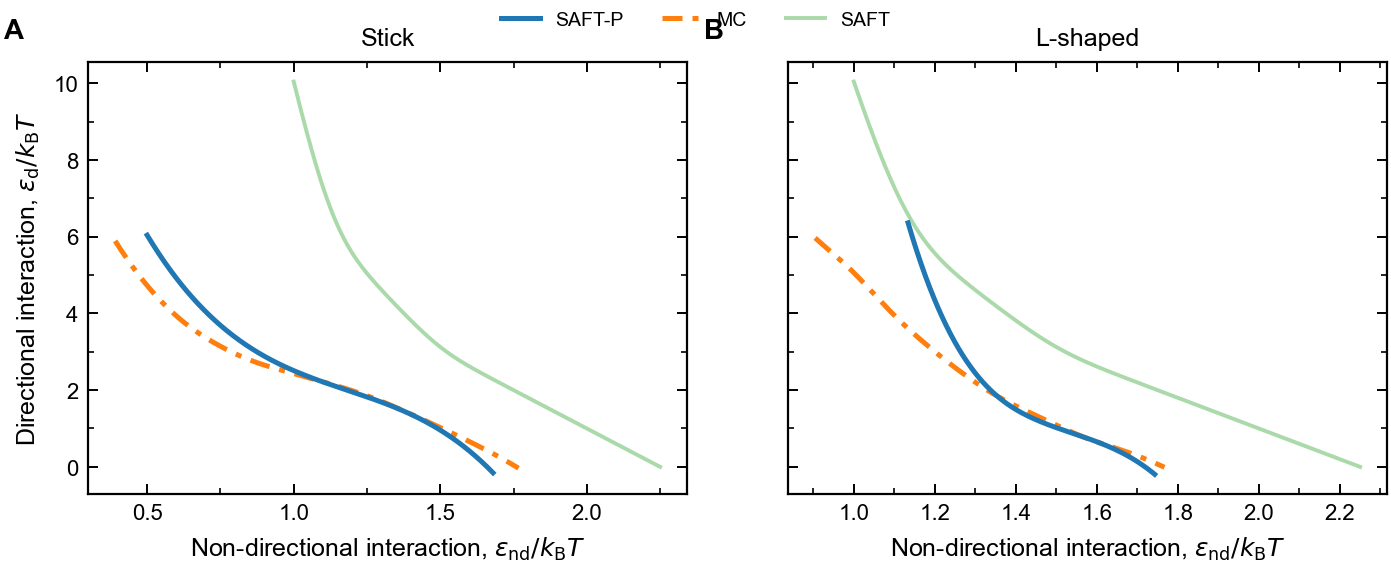

In [17]:

# ---------- available grid points preview (ACS style) ----------
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.8), dpi=200, constrained_layout=True, sharey=True)

for j, (ax, system_name) in enumerate(zip(axes, ["stick", "l"])):
    payload = phase_data[system_name]
    x_saftp, y_saftp = payload["saftp_curve"]
    x_mc, y_mc = payload["mc_curve"]
    x_saft, y_saft = payload["saft_curve"]
    point_df = payload["point_df"]

    ax.plot(x_saftp, y_saftp, label="SAFT-P", zorder=3)
    ax.plot(x_mc, y_mc, linestyle=(0, (4, 2, 1.2, 2)), label="MC", zorder=2)
    ax.plot(x_saft, y_saft, linewidth=1.4, alpha=0.4, label="SAFT", zorder=1)
    #ax.scatter(point_df["eps_c"], point_df["eps_a"], s=8, alpha=0.18, linewidths=0, label="grid points", zorder=0)

    ax.set_title(SYSTEMS[system_name].label)
    apply_axes_style(
        ax,
        xlabel=r"Non-directional interaction, $\epsilon_{\mathrm{nd}}/k_{\mathrm{B}}T$",
        ylabel=r"Directional interaction, $\epsilon_{\mathrm{d}}/k_{\mathrm{B}}T$" if j == 0 else None,
        show_grid=False,
    )
    panel_label(ax, "A" if j == 0 else "B")

handles, labels = axes[0].get_legend_handles_labels()
seen = set()
handles2, labels2 = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        handles2.append(h); labels2.append(l)
fig.legend(handles2, labels2, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03))
save_figure(fig, "available_grid_points_overlay")
plt.show()


In [18]:
# ---------- MANUAL POINT SELECTION ----------
# Edit this list.
# eps_a and eps_c can be exact grid coordinates or approximate values.
# The notebook will snap each request to the nearest valid grid point for that system.

MANUAL_POINT_REQUESTS = [
    {"system": "stick", "name": "S1", "eps_a": 1.8, "eps_c": 0.40},
    {"system": "stick", "name": "S2", "eps_a": 3.8, "eps_c": 0.84},
    {"system": "stick", "name": "S3", "eps_a": 6, "eps_c": 1},
    {"system": "l",     "name": "L1",     "eps_a": 0.60, "eps_c": 1.05},
    {"system": "l",     "name": "L2",     "eps_a": 4.0, "eps_c": 1.30},
    {"system": "l",     "name": "L3",     "eps_a": 2.0, "eps_c": 1.75},

]

# If True, require an exact grid match instead of nearest-neighbor snapping.
REQUIRE_EXACT_GRID_MATCH = False


In [19]:
def snap_manual_points_to_grid(manual_requests, phase_data, require_exact=False):
    rows = []
    for req in manual_requests:
        system = req["system"]
        name = req["name"]
        eps_a_req = float(req["eps_a"])
        eps_c_req = float(req["eps_c"])

        df = phase_data[system]["point_df"].copy()
        if len(df) == 0:
            raise ValueError(f"No grid points available for system {system}.")

        d2 = (df["eps_a"] - eps_a_req) ** 2 + (df["eps_c"] - eps_c_req) ** 2
        idx = int(np.argmin(d2))
        row = df.iloc[idx]

        if require_exact:
            if not (np.isclose(row["eps_a"], eps_a_req) and np.isclose(row["eps_c"], eps_c_req)):
                raise ValueError(
                    f"Requested point ({eps_a_req}, {eps_c_req}) for {system} is not an exact grid point. "
                    f"Nearest available point is ({row['eps_a']}, {row['eps_c']})."
                )

        rows.append({
            "system": system,
            "name": name,
            "eps_a_request": eps_a_req,
            "eps_c_request": eps_c_req,
            "eps_a": float(row["eps_a"]),
            "eps_c": float(row["eps_c"]),
            "gap": float(row["gap"]) if np.isfinite(row["gap"]) else np.nan,
            "snap_distance": float(np.sqrt(d2.iloc[idx])),
        })
    return pd.DataFrame(rows)

selected_points = snap_manual_points_to_grid(
    MANUAL_POINT_REQUESTS,
    phase_data,
    require_exact=REQUIRE_EXACT_GRID_MATCH,
)
selected_points


,system,name,eps_a_request,eps_c_request,eps_a,eps_c,gap,snap_distance
0,stick,S1,1.8,0.40,2.2,1.120,0.222133,8.236504e-01
1,stick,S2,3.8,0.84,3.8,0.840,0.385467,4.440892e-16
2,stick,S3,6.0,1.00,6.0,0.980,0.503067,2.000000e-02
3,l,L1,0.6,1.05,0.7,1.575,0.196000,5.344390e-01
4,l,L2,4.0,1.30,4.0,1.302,0.365867,2.000000e-03
5,l,L3,2.0,1.75,2.0,1.575,0.490000,1.750000e-01


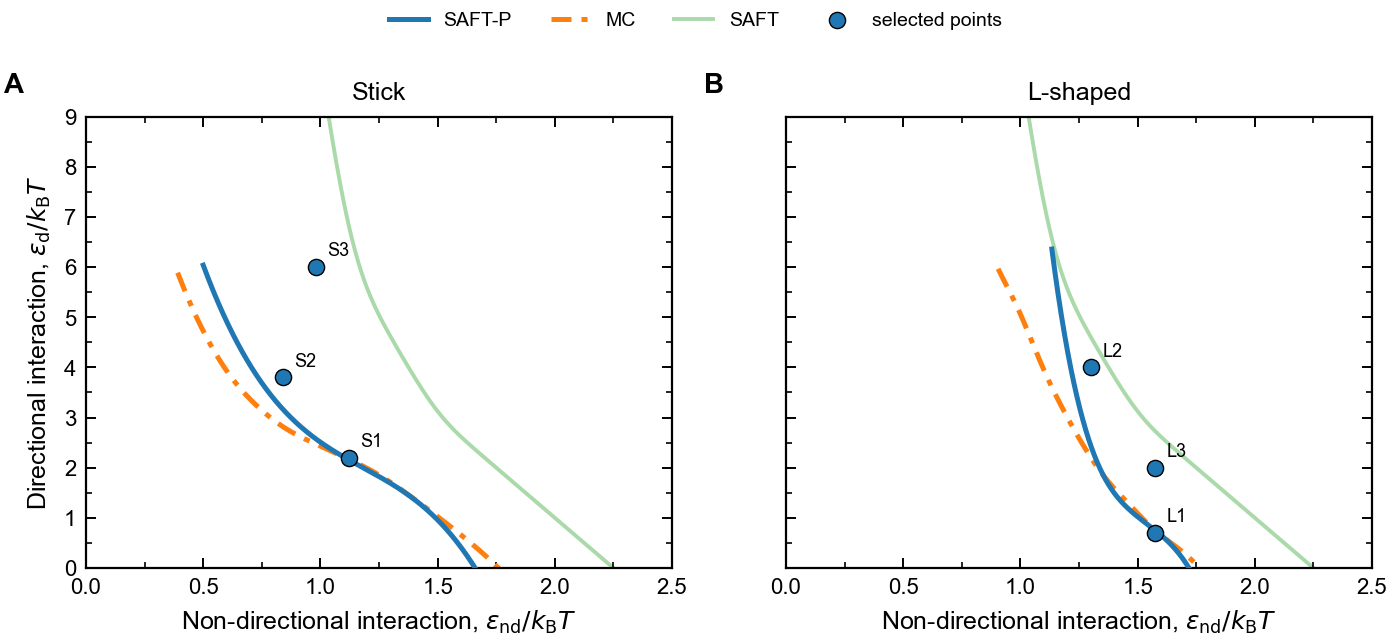

In [20]:

# overlay chosen manual points on the phase diagrams (ACS style)
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.9), dpi=200, constrained_layout=True, sharey=True)

for j, (ax, system_name) in enumerate(zip(axes, ["stick", "l"])):
    payload = phase_data[system_name]
    x_saftp, y_saftp = payload["saftp_curve"]
    x_mc, y_mc = payload["mc_curve"]
    x_saft, y_saft = payload["saft_curve"]
    point_df = payload["point_df"]

    ax.plot(x_saftp, y_saftp, label="SAFT-P", zorder=3)
    ax.plot(x_mc, y_mc, linestyle=(0, (4, 2, 1.2, 2)), label="MC", zorder=2)
    ax.plot(x_saft, y_saft, linewidth=1.4, alpha=0.4, label="SAFT", zorder=1)
    #ax.scatter(point_df["eps_c"], point_df["eps_a"], s=7, alpha=0.10, linewidths=0, label="grid points", zorder=0)

    sub = selected_points[selected_points["system"] == system_name]
    ax.scatter(
        sub["eps_c"], sub["eps_a"], s=34, marker="o",
        edgecolors="black", linewidths=0.5, label="selected points", zorder=5
    )

    for _, row in sub.iterrows():
        ax.annotate(row["name"], (row["eps_c"], row["eps_a"]), xytext=(4, 4), textcoords="offset points", fontsize=6.5)

    ax.set_title(SYSTEMS[system_name].label)
    apply_axes_style(
        ax,
        xlabel=r"Non-directional interaction, $\epsilon_{\mathrm{nd}}/k_{\mathrm{B}}T$",
        ylabel=r"Directional interaction, $\epsilon_{\mathrm{d}}/k_{\mathrm{B}}T$" if j == 0 else None,
        show_grid=False,
    )
    panel_label(ax, "A" if j == 0 else "B")
    ax.set_xlim([0,2.5])
    ax.set_ylim([0,9])
    
handles, labels = axes[0].get_legend_handles_labels()
seen = set()
handles2, labels2 = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        handles2.append(h); labels2.append(l)
fig.legend(handles2, labels2, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 1.03))
save_figure(fig, "manual_selected_points_overlay")
plt.show()


In [21]:
def build_local_mu_grids(mu_center):
    mu_line = np.linspace(mu_center - mu_window_half_width, mu_center + mu_window_half_width, mu_values_line_count)
    mu_mc = np.linspace(mu_center - mu_window_half_width, mu_center + mu_window_half_width, mu_values_mc_count)
    return mu_line, mu_mc

def find_theory_midpoint_from_line(mu_values, occ_values):
    idx = int(np.argmin(np.abs(np.asarray(occ_values) - target_midpoint)))
    return float(np.asarray(mu_values)[idx])

def run_error_analysis_for_point(system_name, eps_a, eps_c):
    config = SYSTEMS[system_name]

    mu_center_ref, midpoint_table = find_midpoint_mu(config, eps_a, eps_c, reference=midpoint_reference)
    mu_line, mu_mc = build_local_mu_grids(mu_center_ref)

    saft_line = evaluate_saft_vs_mu(config, mu_line, eps_a, eps_c)
    saftp_line, saftp_aux = evaluate_saftp_vs_mu(config, mu_line, eps_a, eps_c)

    saft_samples = evaluate_saft_vs_mu(config, mu_mc, eps_a, eps_c)
    saftp_samples, saftp_aux_samples = evaluate_saftp_vs_mu(config, mu_mc, eps_a, eps_c)
    mc_mean, mc_std = evaluate_mc_vs_mu(config, mu_mc, eps_a, eps_c)

    saft_err = saft_samples - mc_mean
    saftp_err = saftp_samples - mc_mean

    mu_mid_saft = find_theory_midpoint_from_line(mu_line, saft_line)
    mu_mid_saftp = find_theory_midpoint_from_line(mu_line, saftp_line)

    row = {
        "system": system_name,
        "eps_a": float(eps_a),
        "eps_c": float(eps_c),
        "mu_center_ref": float(mu_center_ref),
        "mu_mid_saft": float(mu_mid_saft),
        "mu_mid_saftp": float(mu_mid_saftp),
        "mu_mid_err_saft": float(mu_mid_saft - mu_center_ref),
        "mu_mid_err_saftp": float(mu_mid_saftp - mu_center_ref),
        "saft_mae": float(np.mean(np.abs(saft_err))),
        "saftp_mae": float(np.mean(np.abs(saftp_err))),
        "saft_rmse": float(np.sqrt(np.mean(saft_err**2))),
        "saftp_rmse": float(np.sqrt(np.mean(saftp_err**2))),
        "saft_max_abs": float(np.max(np.abs(saft_err))),
        "saftp_max_abs": float(np.max(np.abs(saftp_err))),
        "saft_bias": float(np.mean(saft_err)),
        "saftp_bias": float(np.mean(saftp_err)),
    }
    row["mae_improvement"] = row["saft_mae"] - row["saftp_mae"]
    row["rmse_improvement"] = row["saft_rmse"] - row["saftp_rmse"]

    detail = pd.DataFrame({
        "mu": mu_mc,
        "mc_mean": mc_mean,
        "mc_std": mc_std,
        "saft": saft_samples,
        "saftp": saftp_samples,
        "saft_err": saft_err,
        "saftp_err": saftp_err,
    })

    line_table = pd.DataFrame({
        "mu": mu_line,
        "saft_line": saft_line,
        "saftp_line": saftp_line,
    })

    return row, detail, line_table, midpoint_table

summary_rows = []
detail_tables = {}
line_tables = {}
midpoint_tables = {}

for _, pt in selected_points.iterrows():
    row, detail, line_table, midpoint_table = run_error_analysis_for_point(pt["system"], pt["eps_a"], pt["eps_c"])
    row["name"] = pt["name"]
    row["gap"] = pt["gap"]
    row["eps_a_request"] = pt["eps_a_request"]
    row["eps_c_request"] = pt["eps_c_request"]
    row["snap_distance"] = pt["snap_distance"]
    summary_rows.append(row)
    detail_tables[pt["name"]] = detail
    line_tables[pt["name"]] = line_table
    midpoint_tables[pt["name"]] = midpoint_table

error_summary = pd.DataFrame(summary_rows)
error_summary = error_summary[[
    "name", "system",
    "eps_a_request", "eps_c_request", "eps_a", "eps_c", "snap_distance", "gap",
    "mu_center_ref", "mu_mid_saft", "mu_mid_saftp", "mu_mid_err_saft", "mu_mid_err_saftp",
    "saft_mae", "saftp_mae", "mae_improvement",
    "saft_rmse", "saftp_rmse", "rmse_improvement",
    "saft_max_abs", "saftp_max_abs", "saft_bias", "saftp_bias"
]].sort_values(["system", "name"])
error_summary


,name,system,eps_a_request,eps_c_request,eps_a,eps_c,snap_distance,gap,mu_center_ref,mu_mid_saft,...,saft_mae,saftp_mae,mae_improvement,saft_rmse,saftp_rmse,rmse_improvement,saft_max_abs,saftp_max_abs,saft_bias,saftp_bias
3,L1,l,0.6,1.05,0.7,1.575,5.344390e-01,0.196000,5.0,4.437500,...,0.228999,0.072901,0.156098,0.337938,0.115296,0.222642,0.759918,0.239699,-0.228450,-0.068617
4,L2,l,4.0,1.30,4.0,1.302,2.000000e-03,0.365867,7.0,6.343750,...,0.286728,0.111050,0.175678,0.406385,0.183500,0.222885,0.907659,0.472427,-0.284764,-0.110974
5,L3,l,2.0,1.75,2.0,1.575,1.750000e-01,0.490000,6.0,5.218750,...,0.272521,0.084409,0.188113,0.411250,0.139221,0.272029,0.852612,0.326227,-0.269450,-0.083852
0,S1,stick,1.8,0.40,2.2,1.120,8.236504e-01,0.222133,4.5,3.921875,...,0.194223,0.062773,0.131450,0.310047,0.100769,0.209277,0.727980,0.257572,-0.193160,-0.034138
1,S2,stick,3.8,0.84,3.8,0.840,4.440892e-16,0.385467,5.0,4.718750,...,0.246791,0.023401,0.223390,0.334370,0.035231,0.299138,0.699335,0.076603,-0.245784,-0.006477
2,S3,stick,6.0,1.00,6.0,0.980,2.000000e-02,0.503067,7.5,6.937500,...,0.301202,0.043533,0.257669,0.422287,0.076258,0.346028,0.819209,0.198312,-0.295378,-0.000689


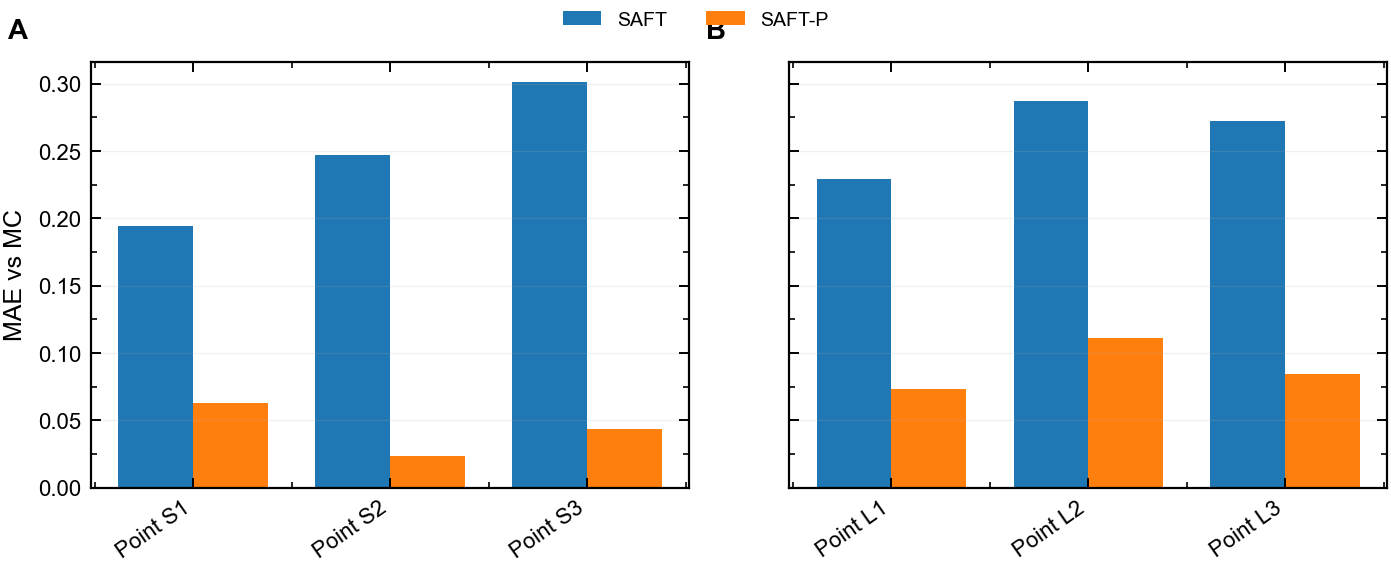

In [22]:

# bar chart: MAE comparison at selected manual points (ACS style)
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.8), dpi=200, constrained_layout=True, sharey=True)

for j, (ax, system_name) in enumerate(zip(axes, ["stick", "l"])):
    sub = error_summary[error_summary["system"] == system_name].reset_index(drop=True)
    x = np.arange(len(sub))
    w = 0.38

    ax.bar(x - w/2, sub["saft_mae"], width=w, label="SAFT")
    ax.bar(x + w/2, sub["saftp_mae"], width=w, label="SAFT-P")
    ax.set_xticks(x)
    ax.set_xticklabels('Point '+ sub["name"], rotation=35, ha="right")
    #ax.set_title(SYSTEMS[system_name].label)
    apply_axes_style(ax, ylabel="MAE vs MC" if j == 0 else None, show_grid=False)
    ax.grid(axis="y", alpha=0.18, linewidth=0.5)
    panel_label(ax, "A" if j == 0 else "B")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
save_figure(fig, "mae_comparison_manual_points")
plt.show()


L1
L2
L3
S1
S2
S3


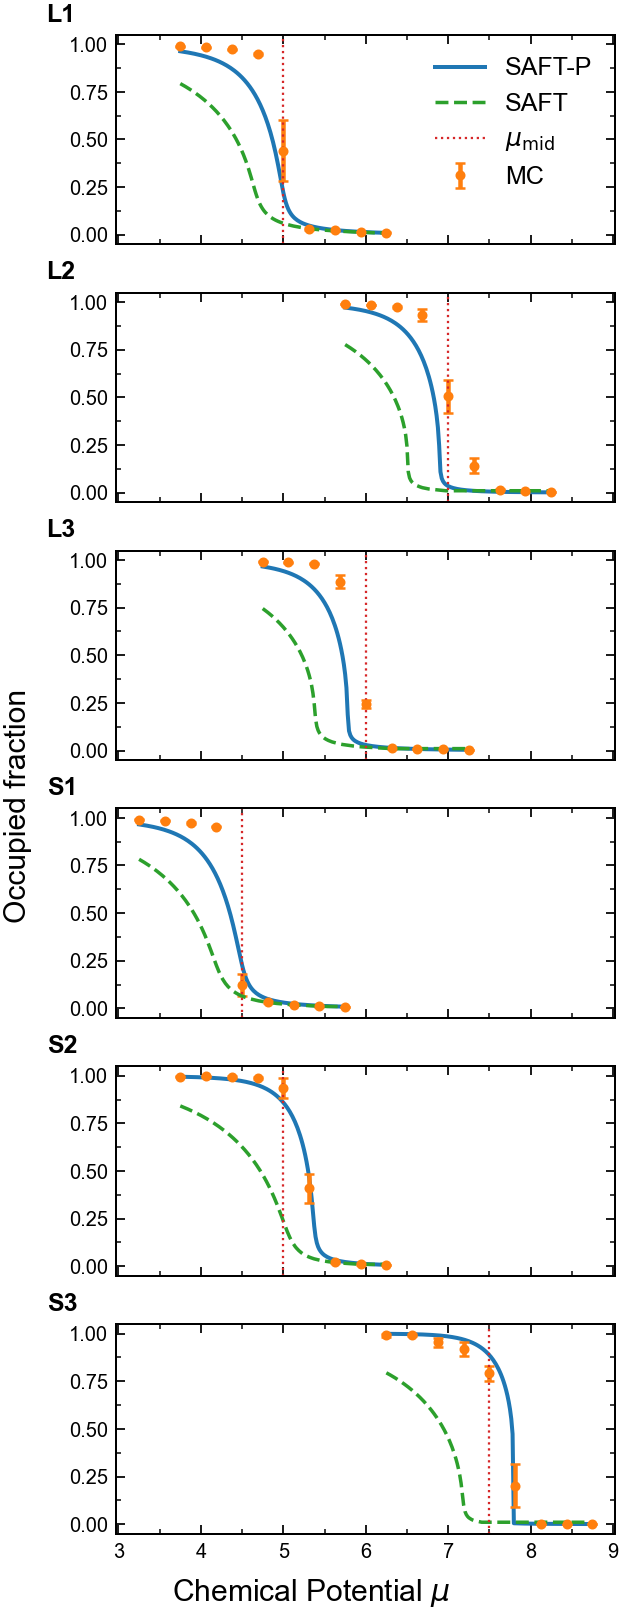

In [23]:
names = error_summary["name"].tolist()
n = len(names)

ncols = 1
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(DOUBLE_COL/2, 1.5 * nrows),
    dpi=180,
    constrained_layout=True,
    squeeze=False,
    sharex=True,
    sharey=True,
)

axes_flat = axes.ravel()
chars=['L1','L2','L3','S1','S2','S3']
for idx, name in enumerate(names):
    ax = axes_flat[idx]
    print(name)
    meta = error_summary[error_summary["name"] == name].iloc[0]
    detail = detail_tables[name]
    line_table = line_tables[name]
    ax.plot(
        line_table["mu"], line_table["saftp_line"],
        lw=1.6, linestyle="-", label="SAFT-P"
    )
    ax.errorbar(
        detail["mu"], detail["mc_mean"], yerr=detail["mc_std"],
        fmt="o", ms=3.0, capsize=2, label="MC"
    )
    ax.plot(
        line_table["mu"], line_table["saft_line"],
        lw=1.4, linestyle="--", label="SAFT"
    )
    
    ax.axvline(
        meta["mu_center_ref"],
        color="tab:red", lw=0.9, linestyle=":",
        label=r"$\mu_{\mathrm{mid}}$"
    )

    # style without repeated labels
    apply_axes_style(ax, xlabel=None, ylabel=None, show_grid=False)
    panel_label(ax, chars[idx])

    if idx == 0:
        ax.legend(frameon=False, loc="best",fontsize=10)

for j in range(n, len(axes_flat)):
    axes_flat[j].axis("off")

fig.supxlabel(r"Chemical Potential $\mu$",fontsize=12)
fig.supylabel("Occupied fraction",fontsize=12)

save_figure(fig, "midpoint_and_local_window_subplots_shared_axes")
plt.show()

In [24]:
# save outputs
out_dir = data_dir / "theory_error_analysis_outputs_manual_points"
out_dir.mkdir(exist_ok=True)

selected_points.to_csv(out_dir / "selected_points_snapped.csv", index=False)
error_summary.to_csv(out_dir / "error_summary_selected_points.csv", index=False)

for name, detail in detail_tables.items():
    detail.to_csv(out_dir / f"{name}_detail.csv", index=False)
for name, line_table in line_tables.items():
    line_table.to_csv(out_dir / f"{name}_line.csv", index=False)
for name, midpoint_table in midpoint_tables.items():
    midpoint_table.to_csv(out_dir / f"{name}_midpoint_search.csv", index=False)

print("Saved outputs to:", out_dir.resolve())


Saved outputs to: <repo>/theory_error_analysis_outputs_manual_points
